# Notebook 6: Pandas Filtering & Sorting
### ML Skills Refresh Curriculum — Module 6 of 30
#### Module 2: The Pandas Masterclass — Part 3 of 3

---

## 🎯 Learning Objectives

| # | Topic | Why It Matters in ML |
|---|-------|----------------------|
| 1 | `loc` vs `iloc` — label vs position | The single most common source of subtle indexing bugs in ML pipelines |
| 2 | Boolean masking — how it works under the hood | Every `.query()`, `sklearn` sample weight, and conditional transform builds on this |
| 3 | Single-condition filtering | Isolating a class, a price band, a date range |
| 4 | Multi-condition filtering (`&`, `\|`, `~`) | Combining criteria to define train/test splits, cohorts, and feature subsets |
| 5 | `sort_values()` | Ranking products, sorting by model confidence scores, leaderboard ordering |
| 6 | `query()` — SQL-like syntax | Cleaner alternative for complex filter expressions |

---

> **Dataset Context:** We use an **e-commerce product catalogue** — 20 products across four categories (Electronics, Books, Clothing, Home & Garden) with columns for price, stock level, customer rating, and whether the item is on sale. It is large enough to make filtering interesting but small enough to verify results by eye.

---
## Section 1 — `loc` vs `iloc`: The Most Important Distinction in Pandas

### 📖 The Logic — Before Any Code

Pandas provides two indexers for selecting rows (and columns). They look almost identical — one letter different — but they operate on completely different systems.

```
df.loc  [ row_label,   column_label  ]   ← LABEL-based
df.iloc [ row_integer, column_integer ]  ← INTEGER POSITION-based
```

---

### `iloc` — Integer Location (think: "i" = integer)

`iloc` works exactly like Python list/NumPy array indexing. It counts from **position 0** regardless of what the index labels say. The labels are completely ignored.

```
df.iloc[0]      → always the FIRST row in memory
df.iloc[-1]     → always the LAST row in memory
df.iloc[2:5]    → rows at positions 2, 3, 4   (stop is EXCLUSIVE — pure Python slice)
df.iloc[0, 2]   → row at position 0, column at position 2
```

### `loc` — Label Location (think: "l" = label)

`loc` uses the **index labels** printed in the left-most column of the DataFrame. When the index is the default `RangeIndex(0, 1, 2, …)`, the labels happen to equal the positions — which is why beginners don't notice the difference. The danger emerges after filtering or sorting, when the labels and positions diverge.

```
df.loc[0]        → the row LABELLED 0 in the index
df.loc[2:5]      → rows labelled 2, 3, 4, 5  (stop is INCLUSIVE — unlike iloc!)
df.loc[0, "name"]→ row labelled 0, column labelled "name"
```

---

### ⚠️ The Critical Gotcha: When Labels ≠ Positions

This is the source of the most common Pandas bug. After any operation that removes or reorders rows **without resetting the index**, the label `5` is no longer at position `5`.

```
Suppose you filter a 10-row DataFrame and keep rows at original labels 3, 7, 9:

  Label  │  Position   Value
  ───────┼─────────────────
    3    │     0        ...
    7    │     1        ...
    9    │     2        ...

  df.iloc[0]  → label 3  (first row in memory)
  df.loc[0]   → KeyError! label 0 no longer exists
  df.loc[3]   → label 3  (the row originally labelled 3)
```

**Rule of thumb:**
- Use `iloc` when you care about **position** (e.g. first 100 rows, every other row).
- Use `loc` when you care about **label** (e.g. the row for customer ID 1042).
- After filtering, call `reset_index(drop=True)` if you want labels and positions to re-align.

---
## Section 2 — Boolean Masking: How Filtering Works Under the Hood

### 📖 The Logic

When you write `df[df["price"] > 100]`, Python executes this in two distinct steps — and understanding those steps lets you build any filter, no matter how complex.

**Step 1 — Generate the boolean mask:**
```python
mask = df["price"] > 100
```
This compares every element of the `price` Series against `100` and returns a **boolean Series** of the same length — `True` where the condition holds, `False` where it does not.

```
index │ price  │ mask
──────┼────────┼──────
  0   │  25.99 │ False
  1   │ 149.99 │ True
  2   │  89.00 │ False
  3   │ 210.00 │ True
```

**Step 2 — Apply the mask to the DataFrame:**
```python
df[mask]   # or equivalently df.loc[mask]
```
Pandas returns only the rows where `mask == True`. Rows with `False` are excluded. The mask acts like a gate — only `True` rows pass through.

**Combining masks with bitwise operators:**

| Operator | Meaning | Example |
|----------|---------|--------|
| `&` | AND — both conditions must be True | `(price > 100) & (rating >= 4.0)` |
| `\|` | OR  — at least one condition must be True | `(category == 'Books') \| (category == 'Clothing')` |
| `~` | NOT — invert the mask | `~(df["on_sale"])` — items NOT on sale |

> **Critical syntax rule:** Each individual condition **must** be wrapped in its own parentheses when combining with `&` or `|`. Without them, Python's operator precedence causes a `ValueError`.
> ```python
> # ❌ Wrong — raises ValueError due to operator precedence
> df[df["price"] > 100 & df["rating"] >= 4.0]
>
> # ✅ Correct — each condition in its own parentheses
> df[(df["price"] > 100) & (df["rating"] >= 4.0)]
> ```

In [1]:
import pandas as pd          # data wrangling
import numpy as np           # numeric operations
import matplotlib.pyplot as plt        # visualisation
import matplotlib.gridspec as gridspec # fine-grained subplot layout

# Show all columns without truncation
pd.set_option("display.max_columns", None)
pd.set_option("display.width",       130)

print(f"Pandas version : {pd.__version__}")

Pandas version : 2.2.2


---
## Section 3 — Building the Product Catalogue Dataset

In [2]:
# ── Product catalogue — 20 items across 4 categories ─────────────────────────
data = {
    "product_name": [
        "Wireless Headphones", "Python Programming Book", "Running Shoes",
        "Coffee Maker",        "Data Science Handbook",   "Yoga Mat",
        "Mechanical Keyboard", "SQL for Beginners",       "Denim Jacket",
        "Air Fryer",           "Noise-Cancel Earbuds",    "The Clean Coder",
        "Linen Trousers",      "Robot Vacuum",            "Machine Learning Book",
        "Winter Coat",         "Smart LED Bulbs",         "Statistics Textbook",
        "Leather Belt",        "Portable Blender"
    ],
    "category": [
        "Electronics", "Books",       "Clothing",    "Home & Garden",
        "Books",        "Clothing",    "Electronics", "Books",
        "Clothing",     "Home & Garden","Electronics", "Books",
        "Clothing",     "Electronics", "Books",
        "Clothing",     "Home & Garden","Books",
        "Clothing",     "Home & Garden"
    ],
    "price_gbp": [
        79.99,  34.99, 65.00, 49.99,
        44.99,  22.50, 109.99, 19.99,
        89.00,  129.99, 149.99, 29.99,
        54.99,  249.99, 39.99,
        175.00, 32.99,  59.99,
        25.99,  38.50
    ],
    "stock": [
        45,  120, 30,  18,
        88,  200, 12,  310,
        55,   7,  23,  145,
        40,   4, 190,
        28,  95,  76,
        180, 62
    ],
    "rating": [
        4.3, 4.7, 3.9, 4.1,
        4.8, 4.2, 4.5, 4.6,
        3.7, 4.0, 4.6, 4.9,
        3.5, 4.4, 4.7,
        4.1, 3.8, 4.5,
        3.6, 4.2
    ],
    "on_sale": [
        True,  False, True,  False,
        False, True,  False, True,
        True,  False, False, False,
        True,  False, False,
        True,  True,  False,
        False, True
    ]
}

df = pd.DataFrame(data)   # wrap the dict into a DataFrame

print(f"Shape: {df.shape}   ← {df.shape[0]} products, {df.shape[1]} columns")
print()
print(df.to_string())     # print the full catalogue for reference

Shape: (20, 6)   ← 20 products, 6 columns

               product_name       category  price_gbp  stock  rating  on_sale
0       Wireless Headphones    Electronics      79.99     45     4.3     True
1   Python Programming Book          Books      34.99    120     4.7    False
2             Running Shoes       Clothing      65.00     30     3.9     True
3              Coffee Maker  Home & Garden      49.99     18     4.1    False
4     Data Science Handbook          Books      44.99     88     4.8    False
5                  Yoga Mat       Clothing      22.50    200     4.2     True
6       Mechanical Keyboard    Electronics     109.99     12     4.5    False
7         SQL for Beginners          Books      19.99    310     4.6     True
8              Denim Jacket       Clothing      89.00     55     3.7     True
9                 Air Fryer  Home & Garden     129.99      7     4.0    False
10     Noise-Cancel Earbuds    Electronics     149.99     23     4.6    False
11          The Clean

In [3]:
# ── Quick inspection ──────────────────────────────────────────────────────────
print("── dtypes ──")
print(df.dtypes)

print("\n── describe() — numeric columns ──")
print(df.describe().round(2))

print("\n── Category counts ──")
print(df["category"].value_counts())

── dtypes ──
product_name     object
category         object
price_gbp       float64
stock             int64
rating          float64
on_sale            bool
dtype: object

── describe() — numeric columns ──
       price_gbp   stock  rating
count      20.00   20.00   20.00
mean       75.19   86.40    4.26
std        60.31   81.60    0.41
min        19.99    4.00    3.50
25%        34.49   26.75    3.98
50%        52.49   58.50    4.25
75%        94.25  126.25    4.60
max       249.99  310.00    4.90

── Category counts ──
category
Books            6
Clothing         6
Electronics      4
Home & Garden    4
Name: count, dtype: int64


---
## Section 4 — `iloc`: Integer-Position Selection

### 📖 The Logic — Recap

`iloc[row_selector, col_selector]` — both selectors use **integer positions** starting at 0. Slicing follows Python convention: `start:stop` where `stop` is **exclusive**.

In [4]:
# ── Single row by position ────────────────────────────────────────────────────
print("── Row at position 0 (first row) ──")
print(df.iloc[0])                # returns a Series — one row, column names as index

print("\n── Row at position -1 (last row) ──")
print(df.iloc[-1])               # negative index counts from the end

# ── Slice of rows by position ─────────────────────────────────────────────────
# positions 0, 1, 2 — stop=3 is EXCLUDED
print("\n── Rows at positions 0, 1, 2 (iloc[0:3]) ──")
print(df.iloc[0:3])

── Row at position 0 (first row) ──
product_name    Wireless Headphones
category                Electronics
price_gbp                     79.99
stock                            45
rating                          4.3
on_sale                        True
Name: 0, dtype: object

── Row at position -1 (last row) ──
product_name    Portable Blender
category           Home & Garden
price_gbp                   38.5
stock                         62
rating                       4.2
on_sale                     True
Name: 19, dtype: object

── Rows at positions 0, 1, 2 (iloc[0:3]) ──
              product_name     category  price_gbp  stock  rating  on_sale
0      Wireless Headphones  Electronics      79.99     45     4.3     True
1  Python Programming Book        Books      34.99    120     4.7    False
2            Running Shoes     Clothing      65.00     30     3.9     True


In [5]:
# ── Selecting rows AND columns by position ───────────────────────────────────
# df.iloc[row_selector, col_selector]

# Rows 0-4, columns 0-2  (positions, not labels)
print("── First 5 rows, first 3 columns (iloc[0:5, 0:3]) ──")
print(df.iloc[0:5, 0:3])

# ── Specific rows AND columns using lists of positions ────────────────────────
# Rows at positions 0, 5, 10 — columns at positions 0, 2, 4
print("\n── Rows [0,5,10], Columns [0,2,4] — specific positions ──")
print(df.iloc[[0, 5, 10], [0, 2, 4]])

# ── Every other row — step slicing ────────────────────────────────────────────
# slice syntax:  start : stop : step
print("\n── Every other row (iloc[::2]) — product_name only ──")
print(df.iloc[::2, 0])   # col position 0 = product_name

── First 5 rows, first 3 columns (iloc[0:5, 0:3]) ──
              product_name       category  price_gbp
0      Wireless Headphones    Electronics      79.99
1  Python Programming Book          Books      34.99
2            Running Shoes       Clothing      65.00
3             Coffee Maker  Home & Garden      49.99
4    Data Science Handbook          Books      44.99

── Rows [0,5,10], Columns [0,2,4] — specific positions ──
            product_name  price_gbp  rating
0    Wireless Headphones      79.99     4.3
5               Yoga Mat      22.50     4.2
10  Noise-Cancel Earbuds     149.99     4.6

── Every other row (iloc[::2]) — product_name only ──
0       Wireless Headphones
2             Running Shoes
4     Data Science Handbook
6       Mechanical Keyboard
8              Denim Jacket
10     Noise-Cancel Earbuds
12           Linen Trousers
14    Machine Learning Book
16          Smart LED Bulbs
18             Leather Belt
Name: product_name, dtype: object


---
## Section 5 — `loc`: Label-Based Selection

### 📖 The Logic — Recap

`loc[row_label, column_label]` — both selectors use **labels**. For the default `RangeIndex`, row labels happen to be integers — but they mean something different from `iloc`.

**Key difference from `iloc` slicing:** `loc` slices are **inclusive** on both ends.
```
df.iloc[2:5]   → positions 2, 3, 4        (5 is excluded)
df.loc[2:5]    → labels 2, 3, 4, 5        (5 is included)
```

In [6]:
# ── Single row by label ───────────────────────────────────────────────────────
print("── Row with label 0 (df.loc[0]) ──")
print(df.loc[0])    # with default RangeIndex, label 0 == position 0

# ── Slice of rows by label — NOTE: stop is INCLUSIVE ─────────────────────────
print("\n── Labels 2 to 5 inclusive (df.loc[2:5]) ──")
print(df.loc[2:5])   # returns 4 rows: labels 2, 3, 4, 5

print("\n── Compare: iloc[2:5] returns only 3 rows (position 2,3,4) ──")
print(df.iloc[2:5])  # returns 3 rows: positions 2, 3, 4

── Row with label 0 (df.loc[0]) ──
product_name    Wireless Headphones
category                Electronics
price_gbp                     79.99
stock                            45
rating                          4.3
on_sale                        True
Name: 0, dtype: object

── Labels 2 to 5 inclusive (df.loc[2:5]) ──
            product_name       category  price_gbp  stock  rating  on_sale
2          Running Shoes       Clothing      65.00     30     3.9     True
3           Coffee Maker  Home & Garden      49.99     18     4.1    False
4  Data Science Handbook          Books      44.99     88     4.8    False
5               Yoga Mat       Clothing      22.50    200     4.2     True

── Compare: iloc[2:5] returns only 3 rows (position 2,3,4) ──
            product_name       category  price_gbp  stock  rating  on_sale
2          Running Shoes       Clothing      65.00     30     3.9     True
3           Coffee Maker  Home & Garden      49.99     18     4.1    False
4  Data Science Ha

In [7]:
# ── Selecting rows AND columns by label ──────────────────────────────────────
# df.loc[row_label_selector, column_label_selector]

# Rows 0 to 4, specific columns by NAME
print("── First 5 rows, product_name + price + rating (loc[0:4, cols]) ──")
print(df.loc[0:4, ["product_name", "price_gbp", "rating"]])

# ── Column slice by name — all rows, columns from 'price_gbp' to 'rating' ────
# This uses the column label order in the DataFrame
print("\n── All rows, columns price_gbp → rating (label slice) ──")
print(df.loc[:, "price_gbp":"rating"].head())
# ':' in the row position means 'all rows'

── First 5 rows, product_name + price + rating (loc[0:4, cols]) ──
              product_name  price_gbp  rating
0      Wireless Headphones      79.99     4.3
1  Python Programming Book      34.99     4.7
2            Running Shoes      65.00     3.9
3             Coffee Maker      49.99     4.1
4    Data Science Handbook      44.99     4.8

── All rows, columns price_gbp → rating (label slice) ──
   price_gbp  stock  rating
0      79.99     45     4.3
1      34.99    120     4.7
2      65.00     30     3.9
3      49.99     18     4.1
4      44.99     88     4.8


In [8]:
# ── The critical gotcha: what happens after filtering (labels ≠ positions) ────

# Filter to keep only Electronics — the original index labels are preserved
df_electronics = df[df["category"] == "Electronics"]

print("── Electronics subset (original index labels retained) ──")
print(df_electronics[["product_name", "category", "price_gbp"]])
print(f"\nIndex labels: {df_electronics.index.tolist()}")
print("              ↑ labels are NOT 0,1,2,3 — they are the original row numbers")

print("\n── df_electronics.iloc[0] → FIRST row in the subset (position 0) ──")
print(df_electronics.iloc[0]["product_name"])   # Wireless Headphones (label 0)

print("\n── df_electronics.iloc[1] → SECOND row in the subset (position 1) ──")
print(df_electronics.iloc[1]["product_name"])   # Mechanical Keyboard (label 6)

# Using loc[1] on this subset would return label 1 — which is NOT in the electronics subset
print("\n── Attempting df_electronics.loc[1] → expects label 1 to exist ──")
try:
    print(df_electronics.loc[1])   # label 1 is not an electronics row → KeyError
except KeyError as e:
    print(f"  KeyError: {e} — label 1 doesn't exist in this subset")

print("\n── Fix: reset_index(drop=True) re-aligns labels with positions ──")
df_elec_reset = df_electronics.reset_index(drop=True)
print(df_elec_reset[["product_name", "category"]]) # labels now 0,1,2,3,4

── Electronics subset (original index labels retained) ──
            product_name     category  price_gbp
0    Wireless Headphones  Electronics      79.99
6    Mechanical Keyboard  Electronics     109.99
10  Noise-Cancel Earbuds  Electronics     149.99
13          Robot Vacuum  Electronics     249.99

Index labels: [0, 6, 10, 13]
              ↑ labels are NOT 0,1,2,3 — they are the original row numbers

── df_electronics.iloc[0] → FIRST row in the subset (position 0) ──
Wireless Headphones

── df_electronics.iloc[1] → SECOND row in the subset (position 1) ──
Mechanical Keyboard

── Attempting df_electronics.loc[1] → expects label 1 to exist ──
  KeyError: 1 — label 1 doesn't exist in this subset

── Fix: reset_index(drop=True) re-aligns labels with positions ──
           product_name     category
0   Wireless Headphones  Electronics
1   Mechanical Keyboard  Electronics
2  Noise-Cancel Earbuds  Electronics
3          Robot Vacuum  Electronics


---
## Section 6 — Boolean Masking in Action

### 📖 The Logic — Recap

Remember the two-step process:
1. Create a boolean Series (the mask)
2. Pass it to `df[mask]` or `df.loc[mask]` to keep only `True` rows

We will first inspect the raw mask object so the mechanism is transparent, then apply it.

In [9]:
# ── Step 1: Generate a boolean Series — inspect it before using it ────────────
# This is what Python creates before filtering even begins

price_mask = df["price_gbp"] > 100    # compare every element to 100

print("── Boolean mask: df['price_gbp'] > 100 ──")
print(price_mask)

# The mask has the same index as df — one True/False per row
print(f"\nMask dtype  : {price_mask.dtype}")
print(f"True  count : {price_mask.sum()}    ← sum() counts True as 1")
print(f"False count : {(~price_mask).sum()} ← ~ inverts the mask")

── Boolean mask: df['price_gbp'] > 100 ──
0     False
1     False
2     False
3     False
4     False
5     False
6      True
7     False
8     False
9      True
10     True
11    False
12    False
13     True
14    False
15     True
16    False
17    False
18    False
19    False
Name: price_gbp, dtype: bool

Mask dtype  : bool
True  count : 5    ← sum() counts True as 1
False count : 15 ← ~ inverts the mask


In [10]:
# ── Step 2: Apply the mask — pass it inside df[ ] or df.loc[ ] ───────────────
df_expensive = df[price_mask]    # equivalent to df.loc[price_mask]

print(f"Products priced above £100  ({len(df_expensive)} results):")
print(df_expensive[["product_name", "category", "price_gbp", "rating"]])

# ── Inline shorthand — create and apply in one step ──────────────────────────
# This is the style you will see most often in practice
print("\n── Inline: df[df['price_gbp'] > 100] (same result) ──")
print(df[df["price_gbp"] > 100][["product_name", "price_gbp"]].to_string())

Products priced above £100  (5 results):
            product_name       category  price_gbp  rating
6    Mechanical Keyboard    Electronics     109.99     4.5
9              Air Fryer  Home & Garden     129.99     4.0
10  Noise-Cancel Earbuds    Electronics     149.99     4.6
13          Robot Vacuum    Electronics     249.99     4.4
15           Winter Coat       Clothing     175.00     4.1

── Inline: df[df['price_gbp'] > 100] (same result) ──
            product_name  price_gbp
6    Mechanical Keyboard     109.99
9              Air Fryer     129.99
10  Noise-Cancel Earbuds     149.99
13          Robot Vacuum     249.99
15           Winter Coat     175.00


---
## Section 7 — Single-Condition Filtering

### 📖 The Logic

Pandas supports all standard comparison operators on Series columns:

| Operator | Meaning | Example |
|----------|---------|--------|
| `==` | Equal to | `df["category"] == "Books"` |
| `!=` | Not equal to | `df["category"] != "Books"` |
| `>` | Greater than | `df["price_gbp"] > 50` |
| `>=` | Greater than or equal | `df["rating"] >= 4.5` |
| `<` | Less than | `df["stock"] < 10` |
| `<=` | Less than or equal | `df["price_gbp"] <= 30` |
| `.isin([...])` | Value in a list | `df["category"].isin(["Books", "Electronics"])` |
| `.str.contains()` | Substring match | `df["product_name"].str.contains("Book")` |

In [11]:
# ── Filter 1: Exact string match ──────────────────────────────────────────────
books = df[df["category"] == "Books"]
print(f"── Books ({len(books)}) ──")
print(books[["product_name", "price_gbp", "rating"]])

# ── Filter 2: Numeric comparison — low stock alert ────────────────────────────
low_stock = df[df["stock"] < 10]    # fewer than 10 units remaining
print(f"\n── Low stock (< 10 units) ({len(low_stock)}) ──")
print(low_stock[["product_name", "category", "stock"]])

# ── Filter 3: Boolean column — items currently on sale ───────────────────────
# A boolean column IS already a mask — no comparison operator needed
on_sale = df[df["on_sale"]]       # equivalent to df[df['on_sale'] == True]
print(f"\n── Items on sale ({len(on_sale)}) ──")
print(on_sale[["product_name", "price_gbp", "on_sale"]])

# ── Filter 4: NOT on sale — using ~ to invert the boolean column ──────────────
not_on_sale = df[~df["on_sale"]]  # ~ flips True→False and False→True
print(f"\n── Items NOT on sale ({len(not_on_sale)}) ──")
print(not_on_sale[["product_name", "on_sale"]].head())

── Books (6) ──
               product_name  price_gbp  rating
1   Python Programming Book      34.99     4.7
4     Data Science Handbook      44.99     4.8
7         SQL for Beginners      19.99     4.6
11          The Clean Coder      29.99     4.9
14    Machine Learning Book      39.99     4.7
17      Statistics Textbook      59.99     4.5

── Low stock (< 10 units) (2) ──
    product_name       category  stock
9      Air Fryer  Home & Garden      7
13  Robot Vacuum    Electronics      4

── Items on sale (9) ──
           product_name  price_gbp  on_sale
0   Wireless Headphones      79.99     True
2         Running Shoes      65.00     True
5              Yoga Mat      22.50     True
7     SQL for Beginners      19.99     True
8          Denim Jacket      89.00     True
12       Linen Trousers      54.99     True
15          Winter Coat     175.00     True
16      Smart LED Bulbs      32.99     True
19     Portable Blender      38.50     True

── Items NOT on sale (11) ──
         

In [12]:
# ── Filter 5: .isin() — match any value in a list ─────────────────────────────
# More readable than chaining multiple == conditions with |

physical_goods = df[df["category"].isin(["Clothing", "Home & Garden"])]
print(f"── Clothing OR Home & Garden ({len(physical_goods)}) ──")
print(physical_goods[["product_name", "category"]].to_string())

# ── Filter 6: .str.contains() — substring match ──────────────────────────────
# case=False → case-insensitive; na=False → treat NaN as no-match (safe default)
has_book = df[df["product_name"].str.contains("Book", case=False, na=False)]
print(f"\n── Products whose name contains 'Book' ({len(has_book)}) ──")
print(has_book[["product_name", "category"]])

── Clothing OR Home & Garden (10) ──
        product_name       category
2      Running Shoes       Clothing
3       Coffee Maker  Home & Garden
5           Yoga Mat       Clothing
8       Denim Jacket       Clothing
9          Air Fryer  Home & Garden
12    Linen Trousers       Clothing
15       Winter Coat       Clothing
16   Smart LED Bulbs  Home & Garden
18      Leather Belt       Clothing
19  Portable Blender  Home & Garden

── Products whose name contains 'Book' (4) ──
               product_name category
1   Python Programming Book    Books
4     Data Science Handbook    Books
14    Machine Learning Book    Books
17      Statistics Textbook    Books


---
## Section 8 — Multi-Condition Filtering (`&`, `|`, `~`)

### 📖 The Logic — Recap

Why can't we use Python's `and` / `or` keywords?

Python's `and` / `or` are **scalar** operators — they expect a single `True`/`False` value and short-circuit. A Pandas Series is not a scalar; it is an array. Passing a Series to `and` raises an ambiguous-truth `ValueError`.

The **bitwise** operators `&`, `|`, `~` operate **element-wise** across the whole array, which is exactly what we need for mask combination.

```
mask_a = [True,  True,  False, False]
mask_b = [True,  False, True,  False]

mask_a & mask_b → [True,  False, False, False]   (AND)
mask_a | mask_b → [True,  True,  True,  False]   (OR)
~mask_a         → [False, False, True,  True ]   (NOT)
```

In [13]:
# ── AND filter (&): BOTH conditions must be True ──────────────────────────────
# Find highly-rated electronics — good picks for a recommendation engine

# Build each mask separately for readability — then combine
mask_electronics = df["category"] == "Electronics"   # True for Electronics rows
mask_high_rating = df["rating"] >= 4.4               # True for rating ≥ 4.4

# Combine: both must be True simultaneously
df_top_electronics = df[mask_electronics & mask_high_rating]

print(f"── Electronics with rating ≥ 4.4  ({len(df_top_electronics)}) ──")
print(df_top_electronics[["product_name", "price_gbp", "rating", "stock"]])

# ── Inline version — exact same logic, more compact ──────────────────────────
# Parentheses around EACH condition are REQUIRED
df_top_elec_inline = df[
    (df["category"] == "Electronics") &
    (df["rating"]   >= 4.4)
]
print(f"\nInline version produces same shape: {df_top_elec_inline.shape == df_top_electronics.shape} ✓")

── Electronics with rating ≥ 4.4  (3) ──
            product_name  price_gbp  rating  stock
6    Mechanical Keyboard     109.99     4.5     12
10  Noise-Cancel Earbuds     149.99     4.6     23
13          Robot Vacuum     249.99     4.4      4

Inline version produces same shape: True ✓


In [14]:
# ── OR filter (|): AT LEAST ONE condition must be True ────────────────────────
# Show products that are either very cheap (< £25) OR very highly rated (≥ 4.8)

df_bargain_or_best = df[
    (df["price_gbp"] < 25) |    # cheap products
    (df["rating"]   >= 4.8)     # OR top-rated products
]

print(f"── Price < £25 OR Rating ≥ 4.8  ({len(df_bargain_or_best)}) ──")
print(df_bargain_or_best[["product_name", "price_gbp", "rating"]].to_string())

── Price < £25 OR Rating ≥ 4.8  (4) ──
             product_name  price_gbp  rating
4   Data Science Handbook      44.99     4.8
5                Yoga Mat      22.50     4.2
7       SQL for Beginners      19.99     4.6
11        The Clean Coder      29.99     4.9


In [15]:
# ── NOT filter (~): invert a mask ────────────────────────────────────────────
# Find non-book products that are also not on sale — full-price non-books

mask_is_book    = df["category"] == "Books"
mask_is_on_sale = df["on_sale"]

# ~ inverts each mask before combining
df_full_price_nonbook = df[
    ~mask_is_book &       # NOT a book
    ~mask_is_on_sale      # AND not on sale
]

print(f"── Not a book AND not on sale  ({len(df_full_price_nonbook)}) ──")
print(df_full_price_nonbook[["product_name", "category", "price_gbp", "on_sale"]])

── Not a book AND not on sale  (6) ──
            product_name       category  price_gbp  on_sale
3           Coffee Maker  Home & Garden      49.99    False
6    Mechanical Keyboard    Electronics     109.99    False
9              Air Fryer  Home & Garden     129.99    False
10  Noise-Cancel Earbuds    Electronics     149.99    False
13          Robot Vacuum    Electronics     249.99    False
18          Leather Belt       Clothing      25.99    False


In [16]:
# ── Three-condition filter: mixing & and | ────────────────────────────────────
# Practical scenario: find 'value-for-money' products to feature on a homepage.
# Definition: rating ≥ 4.2  AND  price between £20 and £80  AND  stock > 20

df_featured = df[
    (df["rating"]    >= 4.2) &      # well-rated
    (df["price_gbp"] >= 20.0) &     # not too cheap (perceived quality)
    (df["price_gbp"] <= 80.0) &     # not too expensive (accessible)
    (df["stock"]     >  20)         # actually in stock
]

print(f"── 'Value-for-Money' featured products  ({len(df_featured)}) ──")
print(df_featured[["product_name", "category", "price_gbp", "rating", "stock"]].to_string())

── 'Value-for-Money' featured products  (8) ──
               product_name       category  price_gbp  rating  stock
0       Wireless Headphones    Electronics      79.99     4.3     45
1   Python Programming Book          Books      34.99     4.7    120
4     Data Science Handbook          Books      44.99     4.8     88
5                  Yoga Mat       Clothing      22.50     4.2    200
11          The Clean Coder          Books      29.99     4.9    145
14    Machine Learning Book          Books      39.99     4.7    190
17      Statistics Textbook          Books      59.99     4.5     76
19         Portable Blender  Home & Garden      38.50     4.2     62


In [17]:
# ── .between(): a cleaner range filter ───────────────────────────────────────
# Equivalent to (df['col'] >= lo) & (df['col'] <= hi) — both bounds inclusive

mid_range = df[df["price_gbp"].between(40, 90)]   # £40 to £90 inclusive

print(f"── Products priced £40–£90  ({len(mid_range)}) ──")
print(mid_range[["product_name", "price_gbp"]].to_string())

── Products priced £40–£90  (7) ──
             product_name  price_gbp
0     Wireless Headphones      79.99
2           Running Shoes      65.00
3            Coffee Maker      49.99
4   Data Science Handbook      44.99
8            Denim Jacket      89.00
12         Linen Trousers      54.99
17    Statistics Textbook      59.99


---
## Section 9 — `query()`: SQL-Like Syntax for Filters

### 📖 The Logic

`df.query()` accepts a **string expression** that Pandas evaluates internally. It is often more readable than bracket-heavy boolean masks, especially for multi-condition filters. Column names with spaces must be wrapped in backticks.

```python
# Boolean mask (verbose but explicit)
df[(df["price_gbp"] > 50) & (df["rating"] >= 4.5)]

# query() (compact and readable)
df.query("price_gbp > 50 and rating >= 4.5")
```

**Referencing Python variables inside a query string:** prefix the variable name with `@`.

In [18]:
# ── query() — basic single condition ──────────────────────────────────────────
print("── query: price_gbp < 30 ──")
print(df.query("price_gbp < 30")[["product_name", "price_gbp"]])

# ── query() — multi-condition with 'and' / 'or' (no parentheses needed) ───────
print("\n── query: Electronics AND rating >= 4.4 ──")
print(df.query("category == 'Electronics' and rating >= 4.4")
       [["product_name", "price_gbp", "rating"]])

# ── query() — referencing an external Python variable with @ ──────────────────
min_rating = 4.5           # defined in Python scope
max_price  = 60.0

print(f"\n── query: rating >= {min_rating} AND price <= £{max_price} ──")
print(df.query("rating >= @min_rating and price_gbp <= @max_price")
       [["product_name", "price_gbp", "rating"]])

# ── query() — 'in' operator (equivalent to .isin()) ──────────────────────────
print("\n── query: category in ['Books', 'Electronics'] ──")
print(df.query("category in ['Books', 'Electronics']")
       [["product_name", "category"]].to_string())

── query: price_gbp < 30 ──
         product_name  price_gbp
5            Yoga Mat      22.50
7   SQL for Beginners      19.99
11    The Clean Coder      29.99
18       Leather Belt      25.99

── query: Electronics AND rating >= 4.4 ──
            product_name  price_gbp  rating
6    Mechanical Keyboard     109.99     4.5
10  Noise-Cancel Earbuds     149.99     4.6
13          Robot Vacuum     249.99     4.4

── query: rating >= 4.5 AND price <= £60.0 ──
               product_name  price_gbp  rating
1   Python Programming Book      34.99     4.7
4     Data Science Handbook      44.99     4.8
7         SQL for Beginners      19.99     4.6
11          The Clean Coder      29.99     4.9
14    Machine Learning Book      39.99     4.7
17      Statistics Textbook      59.99     4.5

── query: category in ['Books', 'Electronics'] ──
               product_name     category
0       Wireless Headphones  Electronics
1   Python Programming Book        Books
4     Data Science Handbook        Bo

---
## Section 10 — Sorting with `sort_values()`

### 📖 The Logic

`sort_values()` reorders the rows of a DataFrame by the values in one or more columns. Key parameters:

| Parameter | Default | What it does |
|-----------|---------|-------------|
| `by` | required | Column name (string) or list of column names to sort by |
| `ascending` | `True` | `True` = smallest first; `False` = largest first. Pass a list to mix directions. |
| `na_position` | `'last'` | Place NaN at `'first'` or `'last'` |
| `inplace` | `False` | Modify in place vs return new DataFrame |

**In ML:** you sort by confidence score to see the top predictions, sort by feature importance to interpret a model, or sort by date to set up a time-based train/test split.

In [19]:
# ── Sort by a single numeric column — ascending (cheapest first) ──────────────
df_by_price_asc = df.sort_values("price_gbp", ascending=True)
print("── Sorted by price: cheapest first ──")
print(df_by_price_asc[["product_name", "price_gbp"]].to_string())

── Sorted by price: cheapest first ──
               product_name  price_gbp
7         SQL for Beginners      19.99
5                  Yoga Mat      22.50
18             Leather Belt      25.99
11          The Clean Coder      29.99
16          Smart LED Bulbs      32.99
1   Python Programming Book      34.99
19         Portable Blender      38.50
14    Machine Learning Book      39.99
4     Data Science Handbook      44.99
3              Coffee Maker      49.99
12           Linen Trousers      54.99
17      Statistics Textbook      59.99
2             Running Shoes      65.00
0       Wireless Headphones      79.99
8              Denim Jacket      89.00
6       Mechanical Keyboard     109.99
9                 Air Fryer     129.99
10     Noise-Cancel Earbuds     149.99
15              Winter Coat     175.00
13             Robot Vacuum     249.99


In [20]:
# ── Sort descending — highest rating first (like a recommendation ranking) ────
df_by_rating = df.sort_values("rating", ascending=False)
print("── Top 5 by rating (descending) ──")
print(df_by_rating[["product_name", "category", "rating"]].head())

── Top 5 by rating (descending) ──
               product_name category  rating
11          The Clean Coder    Books     4.9
4     Data Science Handbook    Books     4.8
1   Python Programming Book    Books     4.7
14    Machine Learning Book    Books     4.7
7         SQL for Beginners    Books     4.6


In [21]:
# ── Sort by MULTIPLE columns — primary key + tiebreaker ──────────────────────
# Sort by category (A–Z) then by rating (highest first) within each category
# Pass a LIST to 'by' and a matching LIST to 'ascending'

df_multi_sort = df.sort_values(
    by=["category", "rating"],          # primary sort: category; secondary: rating
    ascending=[True, False]             # category A→Z, rating best→worst
)

print("── Sorted by Category (A→Z) then Rating (best→worst) ──")
print(df_multi_sort[["product_name", "category", "price_gbp", "rating"]].to_string())

── Sorted by Category (A→Z) then Rating (best→worst) ──
               product_name       category  price_gbp  rating
11          The Clean Coder          Books      29.99     4.9
4     Data Science Handbook          Books      44.99     4.8
1   Python Programming Book          Books      34.99     4.7
14    Machine Learning Book          Books      39.99     4.7
7         SQL for Beginners          Books      19.99     4.6
17      Statistics Textbook          Books      59.99     4.5
5                  Yoga Mat       Clothing      22.50     4.2
15              Winter Coat       Clothing     175.00     4.1
2             Running Shoes       Clothing      65.00     3.9
8              Denim Jacket       Clothing      89.00     3.7
18             Leather Belt       Clothing      25.99     3.6
12           Linen Trousers       Clothing      54.99     3.5
10     Noise-Cancel Earbuds    Electronics     149.99     4.6
6       Mechanical Keyboard    Electronics     109.99     4.5
13            

In [22]:
# ── nlargest() and nsmallest() — shortcut for top / bottom N ─────────────────
# More efficient than sort_values().head(n) for large DataFrames

print("── Top 3 most expensive products (nlargest) ──")
print(df.nlargest(3, "price_gbp")[["product_name", "price_gbp"]])

print("\n── 3 cheapest products (nsmallest) ──")
print(df.nsmallest(3, "price_gbp")[["product_name", "price_gbp"]])

── Top 3 most expensive products (nlargest) ──
            product_name  price_gbp
13          Robot Vacuum     249.99
15           Winter Coat     175.00
10  Noise-Cancel Earbuds     149.99

── 3 cheapest products (nsmallest) ──
         product_name  price_gbp
7   SQL for Beginners      19.99
5            Yoga Mat      22.50
18       Leather Belt      25.99


In [23]:
# ── sort_index(): sort by the row INDEX labels ────────────────────────────────
# Useful after a sort_values() call scrambles the index, and you want it back

# First: scramble the order with a sort
df_scrambled = df.sort_values("rating", ascending=False)
print("── Index after sort_values (scrambled) ──")
print(df_scrambled.index.tolist())

# Restore original row order by sorting the index back to 0, 1, 2, ...
df_restored = df_scrambled.sort_index(ascending=True)
print("\n── Index after sort_index (restored) ──")
print(df_restored.index.tolist())
print(f"\nIdentical to original df: {df.equals(df_restored)} ✓")

── Index after sort_values (scrambled) ──
[11, 4, 1, 14, 7, 10, 17, 6, 13, 0, 5, 19, 15, 3, 9, 2, 16, 8, 18, 12]

── Index after sort_index (restored) ──
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

Identical to original df: True ✓


---
## Section 11 — Combining Filter + Sort: A Practical Workflow

### 📖 The Logic

In practice you almost always **filter first** and **then sort** — or chain both into a single readable expression using Pandas' method chaining. Method chaining means calling multiple methods on successive return values:

```python
result = (
    df
    .loc[boolean_mask]          # filter rows
    .sort_values("col")         # sort result
    .reset_index(drop=True)     # clean up index
    [["col1", "col2"]]          # select columns
)
```

In [24]:
# ── Task: build a 'bargain shortlist' ─────────────────────────────────────────
# Criteria: in-stock (> 15 units), rated ≥ 4.0, price ≤ £75
# Output: sorted by rating descending, then price ascending as tiebreaker

bargain_shortlist = (
    df
    # Step 1 — Filter: three conditions all joined with &
    .loc[
        (df["stock"]     >  15)  &
        (df["rating"]    >= 4.0) &
        (df["price_gbp"] <= 75.0)
    ]
    # Step 2 — Sort: primary = rating (best first), secondary = price (cheapest first)
    .sort_values(["rating", "price_gbp"], ascending=[False, True])
    # Step 3 — Clean index so it reads 0,1,2,...
    .reset_index(drop=True)
    # Step 4 — Select only the columns we care about
    [["product_name", "category", "price_gbp", "stock", "rating", "on_sale"]]
)

print(f"── Bargain Shortlist  ({len(bargain_shortlist)} products) ──")
print(bargain_shortlist.to_string())

── Bargain Shortlist  (9 products) ──
              product_name       category  price_gbp  stock  rating  on_sale
0          The Clean Coder          Books      29.99    145     4.9    False
1    Data Science Handbook          Books      44.99     88     4.8    False
2  Python Programming Book          Books      34.99    120     4.7    False
3    Machine Learning Book          Books      39.99    190     4.7    False
4        SQL for Beginners          Books      19.99    310     4.6     True
5      Statistics Textbook          Books      59.99     76     4.5    False
6                 Yoga Mat       Clothing      22.50    200     4.2     True
7         Portable Blender  Home & Garden      38.50     62     4.2     True
8             Coffee Maker  Home & Garden      49.99     18     4.1    False


In [25]:
# ── Bonus: using .loc to ASSIGN values to a filtered subset ───────────────────
# .loc[row_mask, column_name] = value  → safe in-place assignment
# This is the ONLY safe way to set values conditionally — avoids SettingWithCopyWarning

df_copy = df.copy()    # work on a copy to leave df unchanged

# Tag all products with stock < 10 as 'critical'
df_copy.loc[df_copy["stock"] < 10, "stock_status"] = "critical"   # new column
df_copy.loc[df_copy["stock"].between(10, 30), "stock_status"]      = "low"
df_copy.loc[df_copy["stock"] > 30, "stock_status"]                 = "healthy"

print("── Stock status labels applied via .loc assignment ──")
print(df_copy[["product_name", "stock", "stock_status"]]
      .sort_values("stock")
      .to_string())

── Stock status labels applied via .loc assignment ──
               product_name  stock stock_status
13             Robot Vacuum      4     critical
9                 Air Fryer      7     critical
6       Mechanical Keyboard     12          low
3              Coffee Maker     18          low
10     Noise-Cancel Earbuds     23          low
15              Winter Coat     28          low
2             Running Shoes     30          low
12           Linen Trousers     40      healthy
0       Wireless Headphones     45      healthy
8              Denim Jacket     55      healthy
19         Portable Blender     62      healthy
17      Statistics Textbook     76      healthy
4     Data Science Handbook     88      healthy
16          Smart LED Bulbs     95      healthy
1   Python Programming Book    120      healthy
11          The Clean Coder    145      healthy
18             Leather Belt    180      healthy
14    Machine Learning Book    190      healthy
5                  Yoga Mat    200

---
## Section 12 — Visualisation

### 📖 What We Are Plotting

Four panels that make the filtering and sorting concepts visual:

1. **Price distribution by category** — horizontal box plots showing the spread and median per category, making filtering thresholds intuitive.
2. **Rating vs Price scatter** — coloured by category and annotated with the multi-condition filter region (the 'featured' window from Section 8).
3. **Top 10 products by rating** — a horizontal bar chart of the sort result from Section 10.
4. **Stock status breakdown** — stacked bar showing critical / low / healthy stock counts per category (from the `.loc` assignment in Section 11).

/tmp/ipykernel_12050/2341543423.py:125: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(status_counts.index, rotation=15, ha="right", fontsize=9)


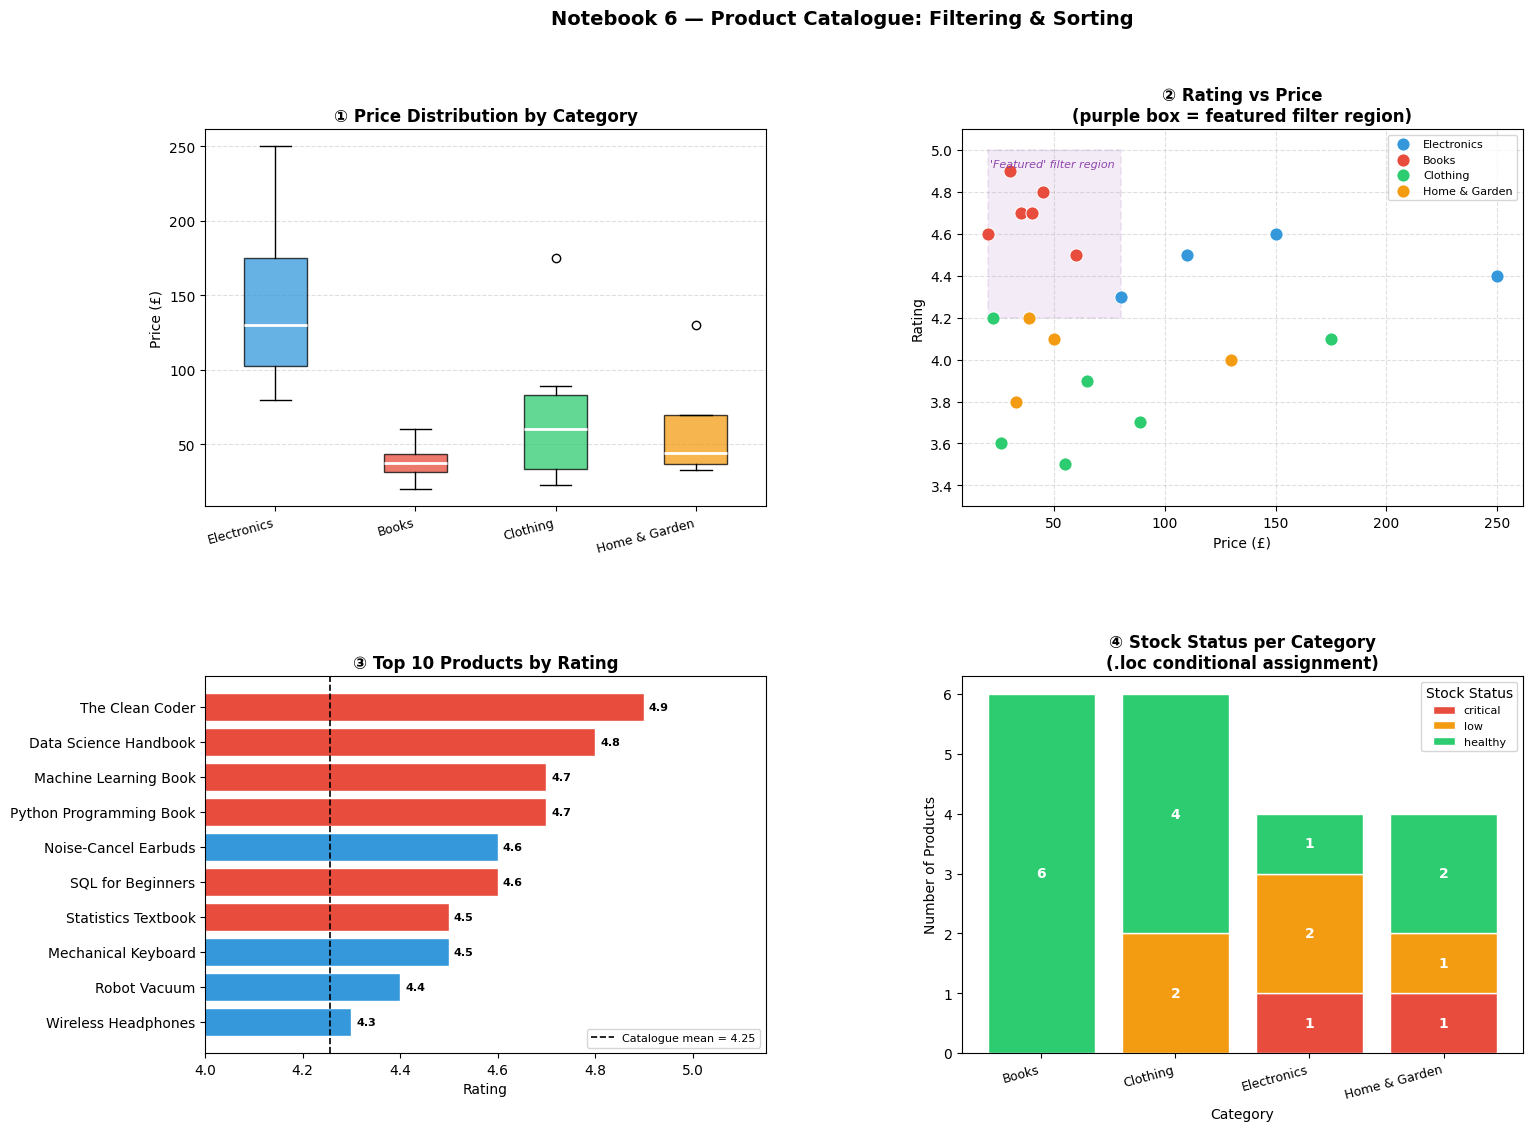


📊 Reading the panels:
  ① Box plots reveal that Electronics has the widest price range (£80–£250);
     Books cluster cheaply (£20–£45). This explains why price threshold
     filters behave very differently across categories.
  ② The purple 'featured' region (£20–£80, rating ≥ 4.2) captures Books
     and a few Clothing items — Electronics are mostly too expensive or
     below the rating bar.
  ③ Books dominate the top-10 by rating (red bars) — The Clean Coder and
     the Data Science Handbook lead. This is the direct output of nlargest().
  ④ Most categories have healthy stock levels (green). The single
     'critical' segment (Home & Garden) matches the Robot Vacuum (4 units)
     we identified in the single-condition filter.



In [26]:
fig = plt.figure(figsize=(17, 12))
fig.suptitle("Notebook 6 — Product Catalogue: Filtering & Sorting",
             fontsize=14, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

cat_colours = {
    "Electronics"  : "#3498db",
    "Books"        : "#e74c3c",
    "Clothing"     : "#2ecc71",
    "Home & Garden": "#f39c12"
}
categories = list(cat_colours.keys())

# ════════ Panel 1: Box plots — price distribution per category ════════════════
price_by_cat = [df.loc[df["category"] == c, "price_gbp"].values for c in categories]

bp = ax1.boxplot(
    price_by_cat,
    vert=True,
    patch_artist=True,           # fill boxes with colour
    notch=False,
    medianprops=dict(color="white", linewidth=2)
)
for patch, cat in zip(bp["boxes"], categories):
    patch.set_facecolor(cat_colours[cat])   # colour each box by category
    patch.set_alpha(0.75)

ax1.set_title("① Price Distribution by Category", fontweight="bold")
ax1.set_xticks(range(1, len(categories) + 1))
ax1.set_xticklabels(categories, rotation=15, ha="right", fontsize=9)
ax1.set_ylabel("Price (£)")
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# ════════ Panel 2: Rating vs Price scatter — with 'featured' window ══════════
for cat, colour in cat_colours.items():
    subset = df[df["category"] == cat]   # filter one category at a time
    ax2.scatter(
        subset["price_gbp"],
        subset["rating"],
        color=colour, s=90, edgecolors="white",
        linewidth=0.7, label=cat, zorder=3
    )

# Draw the 'value-for-money' filter window from Section 8 as a shaded rectangle
from matplotlib.patches import Rectangle
window = Rectangle(
    (20, 4.2),          # (x_left, y_bottom)
    60,                 # width  (£20 to £80 → span = 60)
    0.8,                # height (4.2 to 5.0 → span = 0.8)
    linewidth=1.5, edgecolor="#8e44ad",
    facecolor="#8e44ad", alpha=0.10,
    linestyle="--", zorder=1
)
ax2.add_patch(window)
ax2.text(21, 4.92, "'Featured' filter region",
         fontsize=8, color="#8e44ad", fontstyle="italic")

ax2.set_title("② Rating vs Price\n(purple box = featured filter region)", fontweight="bold")
ax2.set_xlabel("Price (£)")
ax2.set_ylabel("Rating")
ax2.legend(fontsize=8)
ax2.grid(True, linestyle="--", alpha=0.4)
ax2.set_ylim(3.3, 5.1)

# ════════ Panel 3: Top 10 products by rating — horizontal bar ════════════════
top10 = df.nlargest(10, "rating").sort_values("rating", ascending=True)
bar_cols = [cat_colours[c] for c in top10["category"]]

bars = ax3.barh(
    top10["product_name"],
    top10["rating"],
    color=bar_cols,
    edgecolor="white"
)
for bar, val in zip(bars, top10["rating"]):
    ax3.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
             f"{val}", va="center", fontsize=8, fontweight="bold")

ax3.set_title("③ Top 10 Products by Rating", fontweight="bold")
ax3.set_xlabel("Rating")
ax3.set_xlim(4.0, 5.15)
ax3.axvline(x=df["rating"].mean(), color="black", linestyle="--",
            linewidth=1.2, label=f"Catalogue mean = {df['rating'].mean():.2f}")
ax3.legend(fontsize=8)

# ════════ Panel 4: Stock status stacked bar per category ═════════════════════
status_order  = ["critical", "low", "healthy"]
status_colours = {"critical": "#e74c3c", "low": "#f39c12", "healthy": "#2ecc71"}

# Build a pivot-like summary: category × stock_status → count
status_counts = (
    df_copy.groupby(["category", "stock_status"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=status_order, fill_value=0)  # ensure column order
)

bottom = np.zeros(len(status_counts))   # track stacked bar heights
for status in status_order:
    vals = status_counts[status].values
    ax4.bar(
        status_counts.index,
        vals,
        bottom=bottom,
        label=status,
        color=status_colours[status],
        edgecolor="white"
    )
    # Annotate each segment with its count
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0:
            ax4.text(xi, b + v / 2, str(v),
                     ha="center", va="center", fontsize=10, color="white",
                     fontweight="bold")
    bottom += vals   # raise the base for the next segment

ax4.set_title("④ Stock Status per Category\n(.loc conditional assignment)", fontweight="bold")
ax4.set_xlabel("Category")
ax4.set_ylabel("Number of Products")
ax4.set_xticklabels(status_counts.index, rotation=15, ha="right", fontsize=9)
ax4.legend(title="Stock Status", fontsize=8)

plt.savefig("/tmp/nb6_preview.png", dpi=100, bbox_inches="tight")
plt.show()

print("""
📊 Reading the panels:
  ① Box plots reveal that Electronics has the widest price range (£80–£250);
     Books cluster cheaply (£20–£45). This explains why price threshold
     filters behave very differently across categories.
  ② The purple 'featured' region (£20–£80, rating ≥ 4.2) captures Books
     and a few Clothing items — Electronics are mostly too expensive or
     below the rating bar.
  ③ Books dominate the top-10 by rating (red bars) — The Clean Coder and
     the Data Science Handbook lead. This is the direct output of nlargest().
  ④ Most categories have healthy stock levels (green). The single
     'critical' segment (Home & Garden) matches the Robot Vacuum (4 units)
     we identified in the single-condition filter.
""")

---
## ✅ Notebook Summary & Key Takeaways

| Concept | Core rule | Gotcha to remember |
|---------|-----------|--------------------|
| **`iloc`** | Integer position — always counts from 0 | Ignores index labels completely |
| **`loc`** | Label-based — uses the index column | Slicing with `loc` is **inclusive** on both ends |
| **Labels ≠ Positions** | After filtering, call `reset_index(drop=True)` | `loc[3]` ≠ `iloc[3]` once rows have been removed |
| **Boolean mask** | `df["col"] > x` returns a True/False Series | The mask must be the same length as the DataFrame |
| **`&` not `and`** | Use bitwise operators for element-wise combination | Each condition must be in its own `( )` |
| **`~`** | Inverts a boolean mask | `~df["on_sale"]` = items NOT on sale |
| **`.isin()`** | Match any value in a list | Cleaner than chaining multiple `==` with `\|` |
| **`.str.contains()`** | Substring filter on string columns | Always pass `na=False` to avoid NaN errors |
| **`.between(a, b)`** | Range filter inclusive on both ends | Replaces `(col >= a) & (col <= b)` |
| **`query()`** | String-expression filtering | Reference Python variables with `@var_name` |
| **`sort_values(by=[...], ascending=[...])`** | Multi-column sort with mixed directions | Pass lists of equal length to both parameters |
| **`nlargest(n, col)`** | Top N rows by a column | More efficient than `sort_values().head(n)` on big data |
| **`.loc[mask, col] = val`** | Safe conditional assignment | The only correct way — avoids `SettingWithCopyWarning` |

---

